In [6]:
import pandas as pd
import numpy as np
import umap
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_umap(data_df, n_neighbors=15, n_components=2, random_state=42, output_prefix="umap_results"):
    """
    Perform UMAP dimensionality reduction, calculate correlations, and save results.

    Parameters:
        data_df (pd.DataFrame): Input data (features as columns, samples as rows).
        n_neighbors (int): Number of neighbors for UMAP.
        n_components (int): Number of dimensions for UMAP embedding.
        random_state (int): Random state for reproducibility.
        output_prefix (str): Prefix for saving result files.

    Returns:
        embedding_df (pd.DataFrame): UMAP embedding results.
        corr_df (pd.DataFrame): Correlations between original features and UMAP components.
    """
    # Data preprocessing: Scale features
    samples = data_df.index
    features = data_df.columns
    data_scaled = pd.DataFrame(preprocessing.scale(data_df), columns=features, index=samples)
    
    # Perform UMAP
    umap_reducer = umap.UMAP(n_neighbors=n_neighbors, n_components=n_components, random_state=random_state)
    embedding = umap_reducer.fit_transform(data_scaled)
    
    # Save UMAP embedding
    component_names = [f"UMAP-{i + 1}" for i in range(n_components)]
    embedding_df = pd.DataFrame(embedding, index=samples, columns=component_names)
    embedding_path = f"{output_prefix}_embedding.tsv"
    embedding_df.to_csv(embedding_path, sep="\t")
    print(f"UMAP embedding saved to: {embedding_path}")
    
    # Calculate correlations
    corr_arr = np.corrcoef(data_scaled.T, embedding.T)[:len(features), len(features):]
    corr_df = pd.DataFrame(corr_arr, index=features, columns=component_names)
    corr_path = f"{output_prefix}_correlations.tsv"
    corr_df.to_csv(corr_path, sep="\t")
    print(f"Feature correlations saved to: {corr_path}")
    
    return embedding_df, corr_df

def plot_umap(embedding_df, labels=None, figsize=(10, 8), cmap="viridis"):
    """
    Plot the UMAP embedding using fig and ax.

    Parameters:
        embedding_df (pd.DataFrame): UMAP embedding results (e.g., from calculate_umap).
        labels (pd.Series or list): Optional labels for coloring points.
        figsize (tuple): Figure size for the plot.
        cmap (str): Colormap for coloring points.
    """
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    
    if labels is not None:
        sns.scatterplot(
            x=embedding_df.iloc[:, 0],
            y=embedding_df.iloc[:, 1],
            hue=labels,
            palette=cmap,
            legend="full",
            s=50,
            ax=ax  # Pass the axis object
        )
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        sns.scatterplot(
            x=embedding_df.iloc[:, 0],
            y=embedding_df.iloc[:, 1],
            legend=None,
            s=50,
            ax=ax  # Pass the axis object
        )
    
    # Set labels and title
    ax.set_xlabel(embedding_df.columns[0])
    ax.set_ylabel(embedding_df.columns[1])
    ax.set_title("UMAP Embedding")
    
    # Adjust layout
    fig.tight_layout()
    
    return fig, ax





/Users/yingweihu/opt/anaconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding saved to: iris_umap_embedding.tsv
Feature correlations saved to: iris_umap_correlations.tsv


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'UMAP Embedding'}, xlabel='UMAP-1', ylabel='UMAP-2'>)

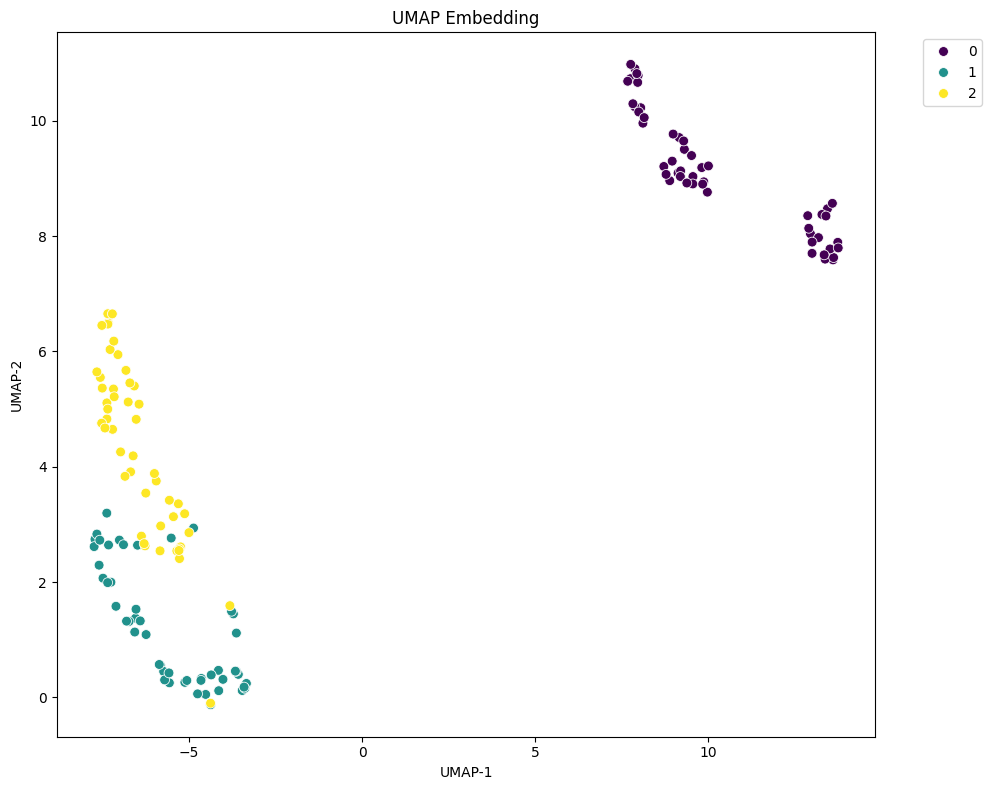

In [7]:
from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names, index=[f"Sample-{i}" for i in range(len(iris.data))])
labels = iris.target  # Class labels for visualization

# Perform UMAP
embedding_df, corr_df = calculate_umap(data, n_neighbors=10, n_components=2, output_prefix="iris_umap")

# Plot UMAP results
plot_umap(embedding_df, labels=labels, cmap="viridis")

In [8]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_tsne_table(data_df, perplexity=30, n_components=2, random_state=42, output_path="tsne_results.tsv"):
    """
    Perform t-SNE dimensionality reduction and save results to a table.

    Parameters:
        data_df (pd.DataFrame): Input data (features as columns, samples as rows).
        perplexity (int): Perplexity parameter for t-SNE.
        n_components (int): Number of dimensions for t-SNE embedding.
        random_state (int): Random state for reproducibility.
        output_path (str): Path to save the t-SNE result table.

    Returns:
        tsne_df (pd.DataFrame): t-SNE results as a DataFrame.
    """
    # Preprocess the data: Standardize features
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_df)
    
    # Perform t-SNE
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state)
    tsne_results = tsne.fit_transform(data_scaled)
    
    # Create a DataFrame for the t-SNE results
    tsne_columns = [f"t-SNE-{i+1}" for i in range(n_components)]
    tsne_df = pd.DataFrame(tsne_results, index=data_df.index, columns=tsne_columns)
    
    # Save to file
    tsne_df.to_csv(output_path, sep="\t")
    print(f"t-SNE results saved to: {output_path}")
    
    return tsne_df


In [9]:
def plot_tsne(tsne_df, labels=None, figsize=(10, 8), cmap="viridis"):
    """
    Plot the t-SNE embedding.

    Parameters:
        tsne_df (pd.DataFrame): t-SNE results (e.g., from calculate_tsne_table).
        labels (pd.Series or list): Optional labels for coloring points.
        figsize (tuple): Figure size for the plot.
        cmap (str): Colormap for coloring points.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    if labels is not None:
        sns.scatterplot(
            x=tsne_df.iloc[:, 0],
            y=tsne_df.iloc[:, 1],
            hue=labels,
            palette=cmap,
            legend="full",
            s=50,
            ax=ax
        )
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        sns.scatterplot(
            x=tsne_df.iloc[:, 0],
            y=tsne_df.iloc[:, 1],
            legend=None,
            s=50,
            ax=ax
        )
    
    ax.set_xlabel(tsne_df.columns[0])
    ax.set_ylabel(tsne_df.columns[1])
    ax.set_title("t-SNE Embedding")
    fig.tight_layout()
    plt.show()


t-SNE results saved to: iris_tsne_results.tsv


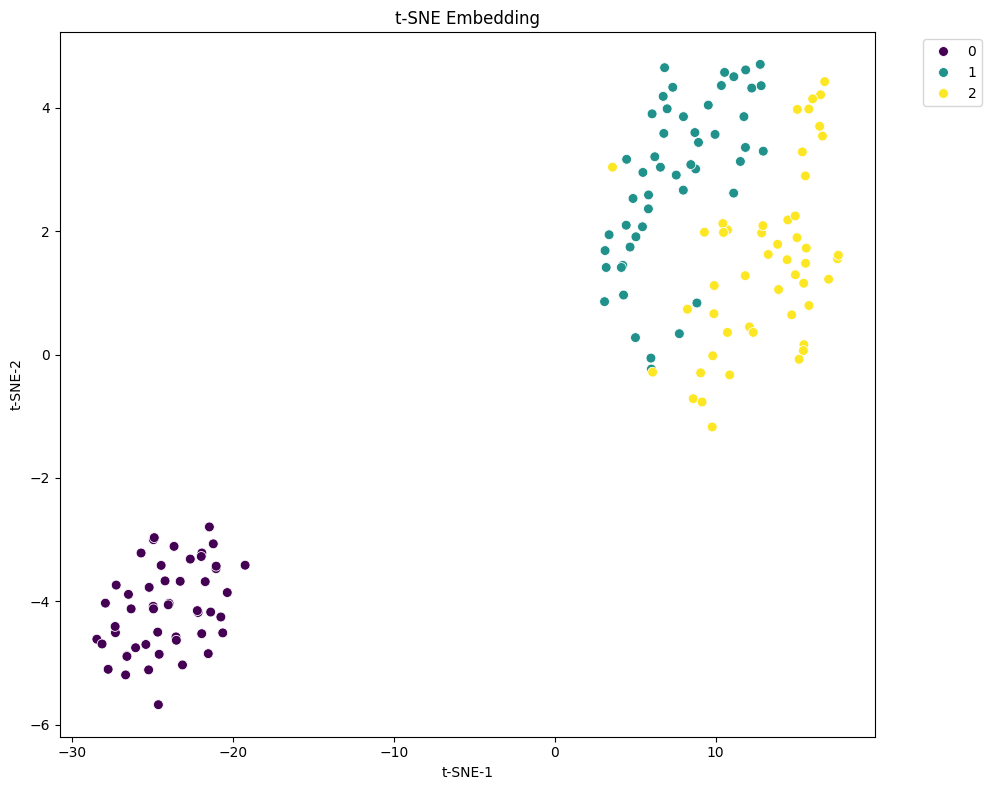

In [10]:
from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names, index=[f"Sample-{i}" for i in range(len(iris.data))])
labels = iris.target  # Class labels for visualization

# Perform t-SNE
tsne_df = calculate_tsne_table(data, perplexity=30, n_components=2, output_path="iris_tsne_results.tsv")

# Plot t-SNE results
plot_tsne(tsne_df, labels=labels, cmap="viridis")